Build Lenet CNN

In [17]:
import tensorflow as tf
tf.compat.v1.disable_eager_execution() # tf.train.saver() does not work in eager mode

def lenet(x):
    x = tf.reshape(x, [-1, 28, 28, 1])

    # Conv1
    conv1 = tf.compat.v1.layers.conv2d(x, 6, 5, activation=tf.nn.relu)
    pool1 = tf.compat.v1.layers.max_pooling2d(conv1, 2, 2)

    # Conv2
    conv2 = tf.compat.v1.layers.conv2d(pool1, 16, 5, activation=tf.nn.relu)
    pool2 = tf.compat.v1.layers.max_pooling2d(conv2, 2, 2)

    # Flatten
    flat = tf.compat.v1.layers.flatten(pool2)

    # Fully connected
    fc1 = tf.compat.v1.layers.dense(flat, 120, activation=tf.nn.relu)
    fc2 = tf.compat.v1.layers.dense(fc1, 84, activation=tf.nn.relu)

    # Output layer
    logits = tf.compat.v1.layers.dense(fc2, 10)

    return logits


Load MNIST, train, save weights.

In [18]:
from tensorflow.keras.datasets import mnist
import numpy as np

# Redefined lenet to use tf.keras.layers due to Keras 3 incompatibility
def lenet(x_input):
    # Reshape input: [-1, 28, 28, 1]
    x_reshaped = tf.reshape(x_input, [-1, 28, 28, 1])

    # Conv1: 6 filters
    conv1 = tf.keras.layers.Conv2D(filters=6, kernel_size=5, activation='relu')(x_reshaped)
    pool1 = tf.keras.layers.MaxPool2D(pool_size=2, strides=2)(conv1)

    # Conv2: 16 filters
    conv2 = tf.keras.layers.Conv2D(filters=16, kernel_size=5, activation='relu')(pool1)
    pool2 = tf.keras.layers.MaxPool2D(pool_size=2, strides=2)(conv2)

    # Flatten
    flat = tf.keras.layers.Flatten()(pool2)

    # Fully connected
    fc1 = tf.keras.layers.Dense(units=120, activation='relu')(flat)
    fc2 = tf.keras.layers.Dense(units=84, activation='relu')(fc1)

    # Output layer (10 classes)
    logits = tf.keras.layers.Dense(units=10)(fc2)

    return logits

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

# Placeholders
X = tf.compat.v1.placeholder(tf.float32, [None, 28, 28])
y = tf.compat.v1.placeholder(tf.int64, [None])

# Model
logits = lenet(X)
loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(
    labels=y, logits=logits))
train_op = tf.compat.v1.train.AdamOptimizer(1e-3).minimize(loss)
acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits,1), y), tf.float32))

# Saver
saver = tf.compat.v1.train.Saver()

# Training
epochs = 5
batch_size = 128

with tf.compat.v1.Session() as sess:
    sess.run(tf.compat.v1.global_variables_initializer())

    for epoch in range(epochs):
        idx = np.random.permutation(len(x_train))
        for i in range(0, len(x_train), batch_size):
            batch_x = x_train[idx[i:i+batch_size]]
            batch_y = y_train[idx[i:i+batch_size]]
            sess.run(train_op, feed_dict={X: batch_x, y: batch_y})

        train_acc = sess.run(acc, feed_dict={X: x_test, y: y_test})
        print("Epoch:", epoch, "Test Accuracy:", train_acc)

    saver.save(sess, "./lenet_mnist.ckpt")
    print("Model saved!")

Epoch: 0 Test Accuracy: 0.9718
Epoch: 1 Test Accuracy: 0.9766
Epoch: 2 Test Accuracy: 0.9834
Epoch: 3 Test Accuracy: 0.9846
Epoch: 4 Test Accuracy: 0.9868
Model saved!


Load Fashion MNIST, then reuse saved weights

In [19]:
from tensorflow.keras.datasets import fashion_mnist

# Redefine lenet to use tf.keras.layers to match the saved checkpoint
def lenet(x_input):
    # Reshape input: [-1, 28, 28, 1]
    x_reshaped = tf.reshape(x_input, [-1, 28, 28, 1])

    # Conv1
    conv1 = tf.keras.layers.Conv2D(filters=6, kernel_size=5, activation='relu', name='conv2d')(x_reshaped)
    pool1 = tf.keras.layers.MaxPool2D(pool_size=2, strides=2, name='max_pooling2d')(conv1)

    # Conv2
    conv2 = tf.keras.layers.Conv2D(filters=16, kernel_size=5, activation='relu', name='conv2d_1')(pool1)
    pool2 = tf.keras.layers.MaxPool2D(pool_size=2, strides=2, name='max_pooling2d_1')(conv2)

    # Flatten
    flat = tf.keras.layers.Flatten(name='flatten')(pool2)

    # Fully connected
    fc1 = tf.keras.layers.Dense(units=120, activation='relu', name='dense')(flat)
    fc2 = tf.keras.layers.Dense(units=84, activation='relu', name='dense_1')(fc1)

    # Output layer
    logits = tf.keras.layers.Dense(units=10, name='dense_2')(fc2)

    return logits

# Load Fashion-MNIST
(x_train_f, y_train_f), (x_test_f, y_test_f) = fashion_mnist.load_data()
x_train_f, x_test_f = x_train_f/255.0, x_test_f/255.0

# New placeholders and graph
tf.compat.v1.reset_default_graph()

Xf = tf.compat.v1.placeholder(tf.float32, [None, 28, 28])
yf = tf.compat.v1.placeholder(tf.int64, [None])

logits_f = lenet(Xf)
loss_f = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(
    labels=yf, logits=logits_f))
train_op_f = tf.compat.v1.train.AdamOptimizer(1e-4).minimize(loss_f)
acc_f = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits_f, 1), yf), tf.float32))

model_vars_to_restore = tf.compat.v1.trainable_variables()
saver = tf.compat.v1.train.Saver(var_list=model_vars_to_restore)

with tf.compat.v1.Session() as sess:
    sess.run(tf.compat.v1.global_variables_initializer())

    saver.restore(sess, "./lenet_mnist.ckpt")
    print("Loaded pretrained weights!")

    for epoch in range(5):
        idx = np.random.permutation(len(x_train_f))
        for i in range(0, len(x_train_f), 128):
            batch_x = x_train_f[idx[i:i+128]]
            batch_y = y_train_f[idx[i:i+128]]
            sess.run(train_op_f, feed_dict={Xf: batch_x, yf: batch_y})

        test_acc = sess.run(acc_f, feed_dict={Xf: x_test_f, yf: y_test_f})
        print("Epoch:", epoch, "Fashion-MNIST Accuracy:", test_acc)


Loaded pretrained weights!
Epoch: 0 Fashion-MNIST Accuracy: 0.7268
Epoch: 1 Fashion-MNIST Accuracy: 0.7602
Epoch: 2 Fashion-MNIST Accuracy: 0.7811
Epoch: 3 Fashion-MNIST Accuracy: 0.7989
Epoch: 4 Fashion-MNIST Accuracy: 0.8018


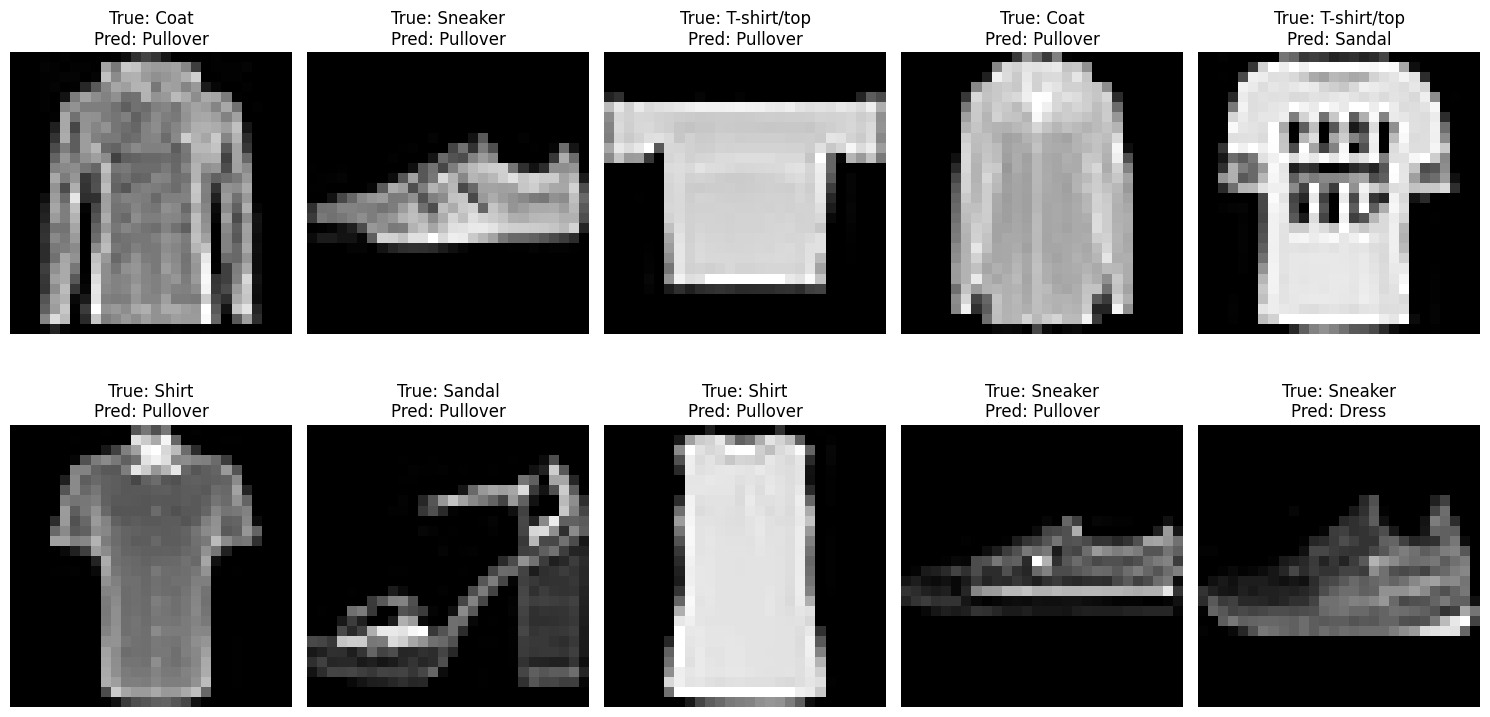

In [20]:
import matplotlib.pyplot as plt

# Fashion-MNIST class names
fashion_mnist_class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Select a random batch of 10 images from the test set
num_samples = 10
random_indices = np.random.choice(len(x_test_f), num_samples, replace=False)
sample_images = x_test_f[random_indices]
sample_true_labels = y_test_f[random_indices]

tf.compat.v1.reset_default_graph()
Xf_pred = tf.compat.v1.placeholder(tf.float32, [None, 28, 28])
logits_pred = lenet(Xf_pred)
predictions = tf.argmax(logits_pred, 1)

saver_pred = tf.compat.v1.train.Saver()

with tf.compat.v1.Session() as sess_pred:
    saver_pred.restore(sess_pred, "./lenet_mnist.ckpt")
    sample_predictions = sess_pred.run(predictions, feed_dict={Xf_pred: sample_images})

# Plotting the images with true and predicted labels
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i], cmap='gray')
    plt.title(f"True: {fashion_mnist_class_names[sample_true_labels[i]]}\nPred: {fashion_mnist_class_names[sample_predictions[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()